# H&M Transaction Data: Product Recommendations 01

In [48]:
import pandas as pd
import numpy as np
from pathlib import Path
import os
import sys
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow import keras
import keras_tuner as kt

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

# data processing classes
from src.customer_features import CustomerFeatureEngineer
from src.product_features import ProductFeatureEngineer
from src.recommendation_training import RecommendationTrainingBuilder

## Data loading

In [2]:
data_path = Path("../data")
customers = pd.read_csv(data_path / 'customer_hm_cleaned.csv')
transactions = pd.read_csv(data_path / 'transactions_hm_cleaned.csv')
articles = pd.read_csv(data_path / 'articles_hm_cleaned.csv')

In [3]:
print("Cleaned Rows of Data:")
print(f"Articles: {len(articles):,}")
print(f"Customers: {len(customers):,}")
print(f"Transactions: {len(transactions):,}")

Cleaned Rows of Data:
Articles: 105,542
Customers: 1,048,575
Transactions: 1,040,101


In [4]:
# Sample data for faster execution
TRANSACTIONS_SAMPLE_SIZE = 500000
transactions_sample = transactions.sample(n=TRANSACTIONS_SAMPLE_SIZE, random_state=67)

CUSTOMER_SAMPLE_SIZE = 500000
# sample_customers = transactions_sample['customer_id'].unique()
customers_sample = customers.sample(n=CUSTOMER_SAMPLE_SIZE, random_state=67)

transactions_df = transactions_sample
customers_df = customers_sample
articles_df = articles

In [5]:
print(f"Customers: using {len(customers_df):,} out of {len(customers):,} available")
print(f"Transactions: using {len(transactions_df):,} out of {len(transactions):,} available")
print(f"Articles: using {len(articles_df):,} out of {len(articles):,} available")

Customers: using 500,000 out of 1,048,575 available
Transactions: using 500,000 out of 1,040,101 available
Articles: using 105,542 out of 105,542 available


## Train, Validation Data Generation

In [6]:
def build_product_recommendation_data(as_of_date, prediction_start_date, prediction_end_date):
    print(f"Data as of date: {as_of_date}")

    cfe = CustomerFeatureEngineer(customers_df=customers_df, transactions_df=transactions_df)
    customer_features = cfe.calculate_all_features(articles_df=articles_df, as_of_date=as_of_date)
    print(f"Customer rows: {len(customer_features):,}")

    pfe = ProductFeatureEngineer(articles_df=articles_df, transactions_df=transactions_df)
    product_features = pfe.calculate_all_features(as_of_date=as_of_date)
    print(f"Product rows: {len(product_features):,}")


    print(f"Prediction period: {prediction_start_date} to {prediction_end_date}")
    builder = RecommendationTrainingBuilder(transactions_df=transactions_df,
                                                customer_features_df=customer_features,
                                                product_features_df=product_features)
    data = builder.build_dataset(prediction_start=prediction_start_date,
                                            prediction_end=prediction_end_date,
                                            negative_ratio=5,
                                            random_state=67)

    print(f"Total rows: {len(data):,}")
    print(f"- Positives: {(data['purchased'] == 1).sum():,}")
    print(f"- Negatives: {(data['purchased'] == 0).sum():,}")
    return data

In [7]:
print("=========TRAINING DATA=========")
train_as_of_date = "2019-09-30"
train_prediction_start_date = "2019-10-01"
train_prediction_end_date = "2019-10-30"
train_data =  build_product_recommendation_data(train_as_of_date, train_prediction_start_date, train_prediction_end_date)

=========TRAINING DATA=========
Data as of date: 2019-09-30
Customer rows: 252,238
Product rows: 37,553
Prediction period: 2019-10-01 to 2019-10-30
Total rows: 83,100
- Positives: 13,850
- Negatives: 69,250


In [8]:
print("\n=========VALIDATION DATA=========")
val_as_of_date = "2019-10-31"
val_prediction_start = "2019-11-01"
val_prediction_end = "2019-11-30"
val_data =  build_product_recommendation_data(val_as_of_date, val_prediction_start, val_prediction_end)


=========VALIDATION DATA=========
Data as of date: 2019-10-31
Customer rows: 268,826
Product rows: 39,630
Prediction period: 2019-11-01 to 2019-11-30
Total rows: 90,432
- Positives: 15,072
- Negatives: 75,360


In [9]:
print("\n=========TEST DATA=========")
test_as_of_date = "2019-11-30"
test_prediction_start = "2019-12-01"
test_prediction_end = "2019-12-31"
test_data =  build_product_recommendation_data(test_as_of_date, test_prediction_start, test_prediction_end)


=========TEST DATA=========
Data as of date: 2019-11-30
Customer rows: 285,551
Product rows: 41,562
Prediction period: 2019-12-01 to 2019-12-31
Total rows: 85,764
- Positives: 14,294
- Negatives: 71,470


In [10]:
feature_cols = [col for col in train_data.columns if col not in ['customer_id', 'article_id', 'purchased']]

print(f"Feature Columns:")
for col in feature_cols:
    print(f"- {col}")


Feature Columns:
- sales_last_7_days
- sales_last_30_days
- days_since_first_sale
- days_since_last_sale
- avg_price
- min_price
- max_price
- product_price_std
- customer_price_std
- num_purchases
- total_spent
- days_since_last_purchase
- avg_transaction_value
- avg_days_between_purchases
- primary_department
- primary_garment_group
- category_diversity


### Categorical features
One hot encode the garment groups. Drop primary department, too many possibilities

In [11]:
print(f"Unique departments: {train_data['primary_department'].nunique()}")
print(f"Unique garment groups: {train_data['primary_garment_group'].nunique()}")

Unique departments: 207
Unique garment groups: 21


In [12]:
train_data = train_data.drop('primary_department', axis=1)
val_data = val_data.drop('primary_department', axis=1)
test_data = test_data.drop('primary_department', axis=1)

train_data = pd.get_dummies(train_data, columns=['primary_garment_group'], prefix='garment')
val_data = pd.get_dummies(val_data, columns=['primary_garment_group'], prefix='garment')
test_data = pd.get_dummies(test_data, columns=['primary_garment_group'], prefix='garment')


all_columns = set(train_data.columns).union(val_data.columns).union(test_data.columns)
print(all_columns)

train_data = train_data.reindex(columns=all_columns, fill_value=0)
val_data = val_data.reindex(columns=all_columns, fill_value=0)
test_data = test_data.reindex(columns=all_columns, fill_value=0)

{'garment_Trousers Denim', 'garment_Skirts', 'avg_transaction_value', 'garment_Special Offers', 'max_price', 'garment_Dresses Ladies', 'garment_Knitwear', 'garment_Socks and Tights', 'garment_Unknown', 'garment_Trousers', 'total_spent', 'garment_Blouses', 'garment_Shorts', 'garment_Woven/Jersey/Knitted mix Baby', 'sales_last_7_days', 'garment_Outdoor', 'purchased', 'customer_price_std', 'garment_Dressed', 'category_diversity', 'garment_Shirts', 'avg_price', 'article_id', 'days_since_last_purchase', 'customer_id', 'garment_Dresses/Skirts girls', 'garment_Jersey Basic', 'product_price_std', 'num_purchases', 'garment_Shoes', 'days_since_last_sale', 'garment_Accessories', 'min_price', 'avg_days_between_purchases', 'garment_Under-, Nightwear', 'sales_last_30_days', 'days_since_first_sale', 'garment_Swimwear', 'garment_Jersey Fancy'}


### X, y split
Outcome variable is `purchased` and 0 or 1 feature

In [13]:
y_train = train_data['purchased']
X_train = train_data.drop(['customer_id', 'article_id', 'purchased'], axis=1)
y_train = train_data['purchased']
print(f"{X_train.shape=}")
print(f"{y_train.shape=}")
X_val = val_data.drop(['customer_id', 'article_id', 'purchased'], axis=1)
y_val = val_data['purchased']
print(f"{X_val.shape=}")
print(f"{y_val.shape=}")
X_test = test_data.drop(['customer_id', 'article_id', 'purchased'], axis=1)
y_test = test_data['purchased']
print(f"{X_test.shape=}")
print(f"{y_test.shape=}")

X_train.shape=(83100, 36)
y_train.shape=(83100,)
X_val.shape=(90432, 36)
y_val.shape=(90432,)
X_test.shape=(85764, 36)
y_test.shape=(85764,)


## Scaling

In [19]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"X_train before scaling - mean: {X_train.mean().mean():.2f}, std: {X_train.std().mean():.2f}")
print(f"X_train after scaling - mean: {X_train_scaled.mean():.2f}, std: {X_train_scaled.std():.2f}")

X_train before scaling - mean: 25.10, std: 19.80
X_train after scaling - mean: -0.00, std: 1.00


## Model building

Build a neural net model with variable number of hidden layers.

- num_features: number of features in dataset
- hidden_layer_sizes: variable array of nodes in hidden layers of neural net
- learning_rate: hyperparameter learning rate
- activation: activation function used within hidden layers
- optimizer: Adam or SGD optimizer

Uses sigmoid activation for the final layer. Reports accuracy.

In [30]:
class MajorityClassifier:  
    def fit(self, X, y):
        y_actual = self._y_actual(y)
        
        self.majority = y_actual.mode()[0]
        self.majority_probability = (y_actual == self.majority).mean()
        self.class_probabilities = y_actual.value_counts(normalize=True).sort_index()
        self.classes = self.class_probabilities.index.to_list()

    def predict(self, X):
        return np.full(len(X), self.majority)

    def evaluate(self, X, y):
        prediction = self.predict(X)
        actual = self._y_actual(y)
        accuracy = (prediction == actual).mean()
        return {'accuracy': accuracy}

    def log_loss(self, y):
        y_actual = self._y_actual(y)
        
        predicted_probabilities = np.tile(self.class_probabilities.values, (len(y), 1))
        
        y_one_hot = np.zeros((len(y), len(self.classes)))
        for i, val in enumerate(y_actual):
            class_idx = self.classes.index(val)
            y_one_hot[i, class_idx] = 1 
        
        log_p = np.log(np.clip(predicted_probabilities, 1e-15, 1))
        return -np.sum(y_one_hot * log_p) / len(y)
    
    def _y_actual(self, y):
        return y.iloc[:, 0] if isinstance(y, pd.DataFrame) else y

In [35]:
baseline = MajorityClassifier()
baseline.fit(X_train_scaled, y_train)

print(f"Baseline predictions: Always predict {baseline.majority}")
print(f"Training accuracy: {baseline.evaluate(X_train_scaled, y_train)['accuracy']:.4f}")
print(f"Training loss: {baseline.log_loss(y_train):.4f}")

print(f"Validation accuracy: {baseline.evaluate(X_val_scaled, y_val)['accuracy']:.4f}")
print(f"Validation loss: {baseline.log_loss(y_val):.4f}")

Baseline predictions: Always predict 0
Training accuracy: 0.8333
Training loss: 0.4506
Validation accuracy: 0.8333
Validation loss: 0.4506


In [14]:
def build_recommendation_model(num_features,
                                hidden_layer_sizes=[512],
                                learning_rate=0.001,
                                activation='relu',
                                optimizer="Adam"):
    tf.keras.backend.clear_session()
    tf.random.set_seed(67)

    model = tf.keras.Sequential()
    for i, layer_units in enumerate(hidden_layer_sizes):
        if i == 0:
            layer = tf.keras.layers.Dense(
                units=layer_units,
                input_shape=(num_features,),
                use_bias=True,
                activation=activation,
                kernel_initializer=tf.initializers.RandomNormal(stddev=0.01),
                bias_initializer=tf.initializers.RandomNormal(stddev=0.01)
            )
        else:
            layer = tf.keras.layers.Dense(
                units=layer_units,
                use_bias=True,
                activation=activation,
                kernel_initializer=tf.initializers.RandomNormal(stddev=0.01),
                bias_initializer=tf.initializers.RandomNormal(stddev=0.01)
            )
        model.add(layer)
    
    model.add(tf.keras.layers.Dense(
        units=1,
        use_bias=True,
        activation='sigmoid',
        kernel_initializer=tf.initializers.RandomNormal(stddev=0.01),
        bias_initializer=tf.initializers.RandomNormal(stddev=0.01)
        )
    )

    if optimizer == "SGD":
        keras_optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)
    elif optimizer == "Adam":
        keras_optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    else:
        keras_optimizer = optimizer

    model.compile(
        loss=tf.keras.losses.BinaryCrossentropy(),
        optimizer=keras_optimizer,
        metrics=['accuracy']
    )
    
    return model

In [72]:
model = build_recommendation_model(X_train_scaled.shape[1],
                                    hidden_layer_sizes=[256],
                                    learning_rate=0.00015,
                                    activation='relu',
                                    optimizer="Adam")
model.summary()
history = model.fit(X_train_scaled, y_train,
                    validation_data=(X_val_scaled, y_val),
                    epochs=10,
                    batch_size=32,
                    verbose=1)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         9,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,729 (38.00 KB)

 Trainable params: 9,729 (38.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
2597/2597 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - accuracy: 0.9062 - loss: 0.3122 - val_accuracy: 0.9155 - val_loss: 0.1815
Epoch 2/10
2597/2597 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.9131 - loss: 0.2372 - val_accuracy: 0.9085 - val_loss: 0.1894
Epoch 3/10
2597/2597 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.9121 - loss: 0.2353 - val_accuracy: 0.9067 - val_loss: 0.1925
Epoch 4/10
2597/2597 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.9119 - loss: 0.2347 - val_accuracy: 0.9070 - val_loss: 0.1919
Epoch 5/10
2597/2597 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.9124 - loss: 0.2343 - val_accuracy: 0.9077 - val_loss: 0.1905
Epoch 6/10
2597/2597 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.9127 - loss: 0.2340 - val_accuracy: 0.9084 - val_loss: 0.1896
Epoch 7/10
2597/2597 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.9128 - loss: 0.2339 - val_accuracy: 0.9089 - val_loss: 0.1891
Epoch 8/10
2597/2597 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.9126 - loss: 0

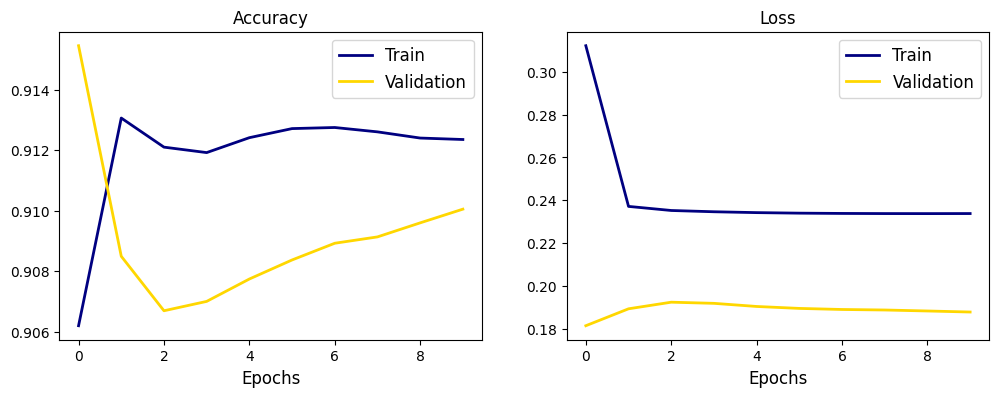

In [75]:
fig = plt.figure(figsize=(12, 4))
ax = fig.add_subplot(1, 2, 1)
plt.plot(history.history['accuracy'], lw=2, color='navy')
plt.plot(history.history['val_accuracy'], lw=2, color='gold')
plt.legend(['Train', 'Validation'], fontsize=12)
ax.set_xlabel('Epochs', size=12)
ax.set_title('Accuracy', size=12)

ax = fig.add_subplot(1, 2, 2)
plt.plot(history.history['loss'], lw=2, color='navy')
plt.plot(history.history['val_loss'], lw=2, color='gold')
plt.legend(['Train', 'Validation'], fontsize=12)
ax.set_xlabel('Epochs', size=12)
ax.set_title('Loss', size=12)

plt.show()

## Test Data

In [76]:
test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)

print(f"\n{'='*60}")
print(f"FINAL MODEL EVALUATION")
print(f"{'='*60}")
print(f"\nBaseline (Majority Class):")
print(f"  Accuracy: 83.33%  |  Loss: 0.4506")
print(f"\nNeural Network Results:")
print(f"  Train Accuracy:      {history.history['accuracy'][-1]*100:.2f}%")
print(f"  Validation Accuracy: {history.history['val_accuracy'][-1]*100:.2f}%")
print(f"  Test Accuracy:       {test_acc*100:.2f}%")
print(f"  Test Loss:           {test_loss:.4f}")
print(f"\nImprovement over Baseline:")
print(f"  +{(test_acc - 0.8333)*100:.2f} percentage points")
print(f"  {((0.4506 - test_loss)/0.4506)*100:.1f}% reduction in loss")


FINAL MODEL EVALUATION

Baseline (Majority Class):
  Accuracy: 83.33%  |  Loss: 0.4506

Neural Network Results:
  Train Accuracy:      91.24%
  Validation Accuracy: 91.01%
  Test Accuracy:       92.60%
  Test Loss:           0.1763

Improvement over Baseline:
  +9.27 percentage points
  60.9% reduction in loss


## Confusion Matrix